# Exploração dos Dados — Avaliação da Alfabetização (INEP)

Análise exploratória das 8 fontes brutas usadas na pipeline, obtidas do dataset
[Avaliação da Alfabetização](https://basedosdados.org/dataset/073a39d4-89cf-4068-b1e8-34ed0d9c0b72)
(Base dos Dados / INEP): resultados (indicador), metas e diretórios de referência.

Objetivo: entender volumetria, granularidade, nulos estruturais e a relação entre
as tabelas antes de desenhar as transformações Bronze → Silver → Gold.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from pipeline.batch.config import RAW_DIR, TABELAS, REDE_MAP

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100


## 1. Volumetria das fontes

In [2]:
resumo = []
for nome, cfg in TABELAS.items():
    caminho = RAW_DIR / cfg["raw_file"]
    tamanho_mb = caminho.stat().st_size / 1024 / 1024 if caminho.exists() else None
    resumo.append({"tabela": nome, "arquivo": cfg["raw_file"], "tamanho_mb": round(tamanho_mb, 1) if tamanho_mb else None,
                    "obrigatoria": cfg["obrigatoria"], "descricao": cfg["descricao"]})
df_resumo = pd.DataFrame(resumo)
df_resumo

,tabela,arquivo,tamanho_mb,obrigatoria,descricao
0,indicador_municipio,br_inep_avaliacao_alfabetizacao_municipio.csv,1.3,True,Resultado (taxa de alfabetização) por municípi...
1,indicador_uf,br_inep_avaliacao_alfabetizacao_uf.csv,0.0,True,"Resultado (taxa de alfabetização) por UF, séri..."
2,meta_brasil,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,0.0,True,Metas nacionais de alfabetização (trajetória 2...
3,meta_uf,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,0.0,True,Metas estaduais de alfabetização (trajetória 2...
4,meta_municipio,br_inep_avaliacao_alfabetizacao_meta_alfabetiz...,0.7,True,Metas municipais de alfabetização (trajetória ...
5,alunos,br_inep_avaliacao_alfabetizacao_alunos.csv,213.7,True,Microdados individuais de desempenho dos aluno...
6,diretorio_municipio,br_bd_diretorios_brasil_municipio.csv,1.3,True,Diretório de municípios brasileiros (chave de ...
7,diretorio_uf,br_bd_diretorios_brasil_uf.csv,0.0,True,Diretório de unidades federativas (chave de re...


## 2. Resultado municipal (indicador_municipio) — a tabela mais granular de resultado

In [3]:
df_mun = pd.read_csv(RAW_DIR / TABELAS["indicador_municipio"]["raw_file"], dtype={"id_municipio": "str"})
print(df_mun.shape)
df_mun.head()

(23995, 15)


,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,1101609,2,3,50.70,745.6802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,1101807,2,3,55.69,752.3724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Anos disponíveis: [np.int64(2023), np.int64(2024)]

Distribuição de 'rede' (código numérico, ver REDE_MAP em config.py):
rede
Municipal    10896
Pública      10466
Estadual      2235
Total          398
Name: count, dtype: int64


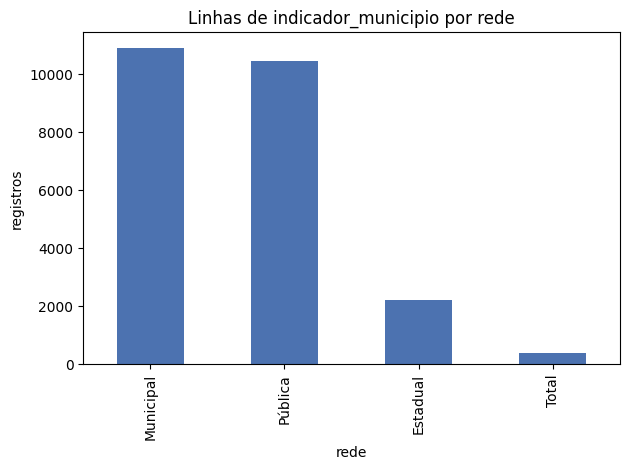

In [4]:
print("Anos disponíveis:", sorted(df_mun["ano"].unique()))
print()
print("Distribuição de 'rede' (código numérico, ver REDE_MAP em config.py):")
contagem_rede = df_mun["rede"].map(REDE_MAP).value_counts()
print(contagem_rede)

contagem_rede.plot(kind="bar", color="#4C72B0", title="Linhas de indicador_municipio por rede")
plt.ylabel("registros")
plt.tight_layout()
plt.show()

In [5]:
pct_nulos = (df_mun.isnull().mean() * 100).round(1).sort_values(ascending=False)
pct_nulos[pct_nulos > 0]

proporcao_aluno_nivel_0    48.1
proporcao_aluno_nivel_6    48.1
proporcao_aluno_nivel_5    48.1
proporcao_aluno_nivel_4    48.1
proporcao_aluno_nivel_3    48.1
proporcao_aluno_nivel_2    48.1
proporcao_aluno_nivel_1    48.1
proporcao_aluno_nivel_7    48.1
proporcao_aluno_nivel_8    48.1
dtype: float64

As colunas `proporcao_aluno_nivel_*` e `media_portugues` só existem a partir da
vintage 2024 — por isso aparecem com ~30% de nulos (proporcionais aos ~30% das
linhas que são de 2023). Isso é estrutural, não um problema de qualidade;
o script de qualidade (`quality/validacao_dados.py`) já reflete isso no limiar
de nulos aceito para esta tabela.

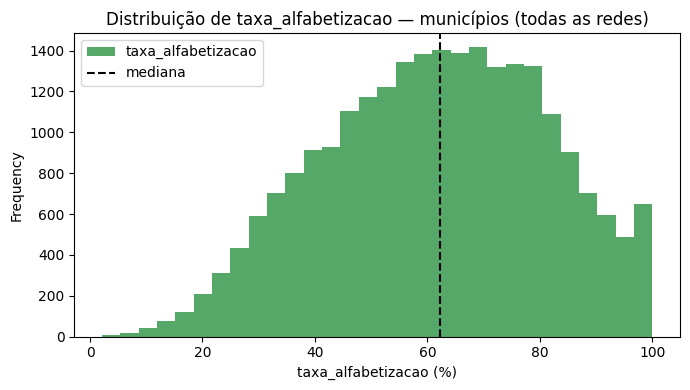

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
df_mun["taxa_alfabetizacao"].dropna().plot(kind="hist", bins=30, color="#55A868", ax=ax)
ax.axvline(df_mun["taxa_alfabetizacao"].median(), color="black", linestyle="--", label="mediana")
ax.set_title("Distribuição de taxa_alfabetizacao — municípios (todas as redes)")
ax.set_xlabel("taxa_alfabetizacao (%)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Metas — formato largo (uma coluna por ano-alvo 2024-2030)

In [7]:
df_meta_mun = pd.read_csv(RAW_DIR / TABELAS["meta_municipio"]["raw_file"], dtype={"id_municipio": "str"})
print(df_meta_mun.shape)
print("rede (escopo da meta municipal):", df_meta_mun["rede"].unique())
df_meta_mun.head()

(10704, 13)
rede (escopo da meta municipal): ['Municipal']


,ano,id_municipio,rede,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,percentual_participacao
0,2023,4301750,Municipal,NaN,NaN,14.05,23.65,37.00,52.68,67.85,80,NaN,NaN
1,2024,4301750,Municipal,4.40,NaN,14.05,23.65,37.00,52.68,67.85,80,0.0,92.59
2,2024,2406908,Municipal,42.86,7.94,14.05,23.65,37.00,52.68,67.85,80,1.0,84.00
3,2023,2406908,Municipal,4.40,7.94,14.05,23.65,37.00,52.68,67.85,80,0.0,82.14
4,2023,1718501,Municipal,4.60,8.25,14.48,24.16,37.49,53.03,68.00,80,0.0,95.65


Cada linha é uma **vintage** (ano de publicação/revisão da trajetória) com uma
coluna por ano-alvo. A Silver despivota isso para formato long (`ano_meta`,
`valor_meta`), mantendo por ano-alvo apenas a vintage mais recente — ver
`02_pipeline_bronze_silver.ipynb`.

## 4. Diretórios de referência (nome de município/UF)

In [8]:
df_dir_mun = pd.read_csv(RAW_DIR / TABELAS["diretorio_municipio"]["raw_file"], dtype={"id_municipio": "str"})
df_dir_uf = pd.read_csv(RAW_DIR / TABELAS["diretorio_uf"]["raw_file"])
print(f"{len(df_dir_mun):,} municípios | {len(df_dir_uf)} UFs")
df_dir_mun[["id_municipio", "nome", "sigla_uf", "nome_uf", "nome_regiao"]].sample(5, random_state=42)

5,571 municípios | 27 UFs


,id_municipio,nome,sigla_uf,nome_uf,nome_regiao
1168,2403004,Cruzeta,RN,Rio Grande do Norte,Nordeste
765,2201150,Baixa Grande do Ribeiro,PI,Piauí,Nordeste
465,2109452,Raposa,MA,Maranhão,Nordeste
1117,2411908,São Francisco do Oeste,RN,Rio Grande do Norte,Nordeste
4934,4316758,Santa Clara do Sul,RS,Rio Grande do Sul,Sul


`indicador_municipio` e `meta_municipio` só trazem `id_municipio` — sem nome do
município nem UF. É por isso que a integração na Silver faz o join com
`diretorio_municipio` (ver dica do enunciado): sem ele, a Gold não teria como
agrupar/exibir por UF.

## 5. Alunos (microdados) — a fonte mais volumosa

In [9]:
df_alunos_amostra = pd.read_csv(RAW_DIR / TABELAS["alunos"]["raw_file"], nrows=200_000,
                                 dtype={"id_municipio": "str", "id_escola": "str", "id_aluno": "str"})
print("Amostra (200k de ~3.87M linhas totais):")
print(df_alunos_amostra["alfabetizado"].value_counts(normalize=True).round(3))
print()
print("rede (código):", df_alunos_amostra["rede"].map(REDE_MAP).value_counts().to_dict())

Amostra (200k de ~3.87M linhas totais):
alfabetizado
1    0.511
0    0.489
Name: proportion, dtype: float64

rede (código): {'Municipal': 177494, 'Estadual': 22503, 'Privada': 3}


A tabela `alunos` só contém os códigos de rede 2, 3 e 4 (Estadual/Municipal/Privada) —
nunca os agregados 0 ("Total") ou 5 ("Pública"), que só existem nas tabelas já
agregadas (`indicador_municipio`/`indicador_uf`). Essa foi a evidência usada para
confirmar o `REDE_MAP` em `config.py`, já que o dicionário oficial do BigQuery
não estava acessível sem credenciais.

## Conclusões

- 8 fontes: 2 diretórios de referência, 3 tabelas de resultado (indicador) e
  3 de meta — **sem tabela de resultado nacional própria** (a série Brasil é
  derivada de `meta_brasil.taxa_alfabetizacao`).
- `rede` é um código numérico nas tabelas de resultado/alunos, mas já vem como
  texto nas tabelas de meta — precisa de decodificação e de cuidado ao comparar
  entre tabelas (ver notebook 2).
- Nomes de município/UF exigem join com os diretórios — nenhuma tabela de
  indicador ou meta os traz nativamente.
- Nulos em `proporcao_aluno_nivel_*` são estruturais (vintage 2023 não coletou
  essas colunas), não devem ser tratados como defeito de qualidade.